In [1]:
import numpy as np
import pandas as pd

In [3]:
fold0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dots/fold0_0.5_selected_genomic_windows_centered_results.tsv", sep="\t")
fold0["fold"] = [0 for i in range(len(fold0))]

In [4]:
fold1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dots/fold1_0.5_selected_genomic_windows_centered_results.tsv", sep="\t")
fold1["fold"] = [1 for i in range(len(fold1))]

In [5]:
fold2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dots/fold2_0.5_selected_genomic_windows_centered_results.tsv", sep="\t")
fold2["fold"] = [2 for i in range(len(fold2))]

In [6]:
df = pd.concat([fold0, fold1, fold2], ignore_index=True)

In [7]:
len(df)

164

In [11]:
df

,chrom,start,end,fold,PearsonR,flat_start,flat_end,centered_start,centered_end,centered_flat_start,...,FIMO_sum_slice0,FIMO_max_slice0,orientation_slice0,positions_slice0,init_CTCFs_num_slice1,CTCFs_num_slice1,FIMO_sum_slice1,FIMO_max_slice1,orientation_slice1,positions_slice1
0,chr1,37793792,39104512,0,0.861165,195.0,323.0,37799936,39110656,192,...,0.000000,0.000000,no,(),0,0,0.000000,0.000000,no,()
1,chr11,65921024,67231744,0,0.746112,76.0,199.0,65677312,66988032,195,...,0.000000,0.000000,no,(),0,2,24.256002,15.072976,++,"[(221, 240), (1545, 1564)]"
2,chr3,38414336,39725056,0,0.670098,198.0,422.0,38524928,39835648,144,...,0.000000,0.000000,no,(),0,0,0.000000,0.000000,no,()
3,chr3,40978432,42289152,0,0.754782,82.0,182.0,40724480,42035200,206,...,0.000000,0.000000,no,(),0,0,0.000000,0.000000,no,()
4,chr3,51795968,53106688,0,0.855747,247.0,416.0,51949568,53260288,172,...,0.000000,0.000000,no,(),0,3,37.456563,18.233642,++-,"[(1127, 1146), (2036, 2055), (1948, 1967)]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,chr9,99520512,100831232,2,0.903110,188.0,332.0,99528704,100839424,184,...,0.000000,0.000000,no,(),1,1,18.634284,18.634284,-,"[(266, 285)]"
160,chr9,101486592,102797312,2,0.841365,58.0,329.0,101357568,102668288,121,...,20.066443,10.952771,+-,"[(76, 95), (63, 82)]",0,1,8.931376,8.931376,-,"[(333, 352)]"
161,chr9,104108032,105418752,2,0.792664,193.0,360.0,104148992,105459712,173,...,9.848777,9.848777,+,"[(2040, 2059)]",1,1,9.314049,9.314049,+,"[(271, 290)]"
162,chr9,111015936,112326656,2,0.832669,222.0,341.0,111067136,112377856,197,...,45.839267,19.872834,++-,"[(372, 391), (1991, 2010), (369, 388)]",0,1,13.304279,13.304279,+,"[(1919, 1938)]"


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

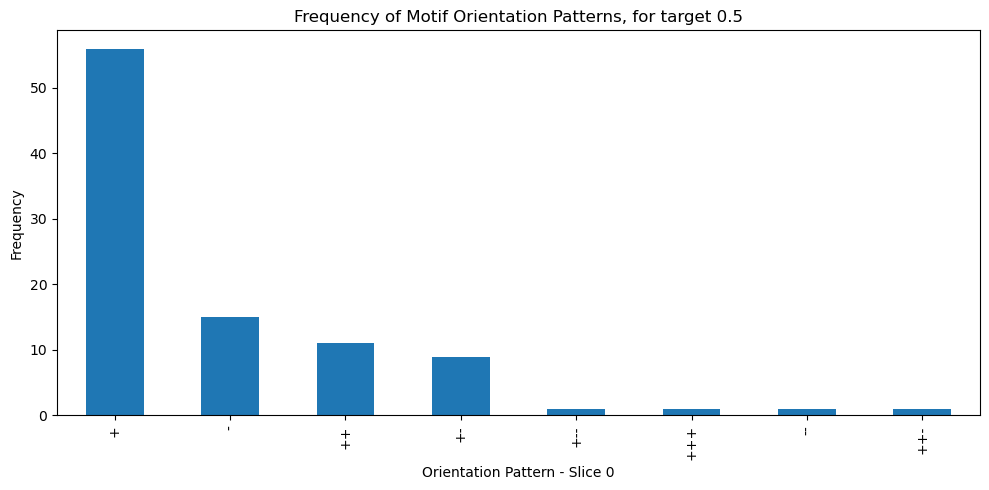

In [13]:
orientation_counts = df[df['orientation_slice0'] != "no"]['orientation_slice0'].value_counts()

# Plot
plt.figure(figsize=(10, 5))
orientation_counts.plot(kind='bar')
plt.xlabel("Orientation Pattern - Slice 0")
plt.ylabel("Frequency")
plt.title("Frequency of Motif Orientation Patterns, for target 0.5")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

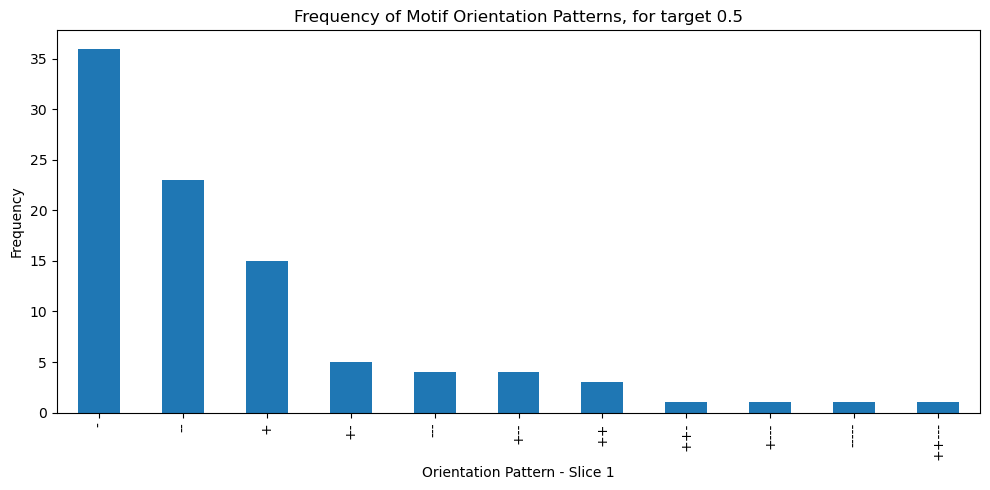

In [14]:
orientation_counts = df[df['orientation_slice1'] != "no"]['orientation_slice1'].value_counts()

# Plot
plt.figure(figsize=(10, 5))
orientation_counts.plot(kind='bar')
plt.xlabel("Orientation Pattern - Slice 1")
plt.ylabel("Frequency")
plt.title("Frequency of Motif Orientation Patterns, for target 0.5")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [34]:
df["orientation"] = np.where(
    (df["orientation_slice0"] == "no") | (df["orientation_slice1"] == "no"),
    "no",
    df["orientation_slice0"] + df["orientation_slice1"]
)

In [32]:
# df["orientation"] = df.apply(
#     lambda row: "no"
#     if row["orientation_slice0"] == "no" and row["orientation_slice1"] == "no"
#     else row["orientation_slice0"].replace("no", "") + row["orientation_slice1"].replace("no", ""),
#     axis=1
# )

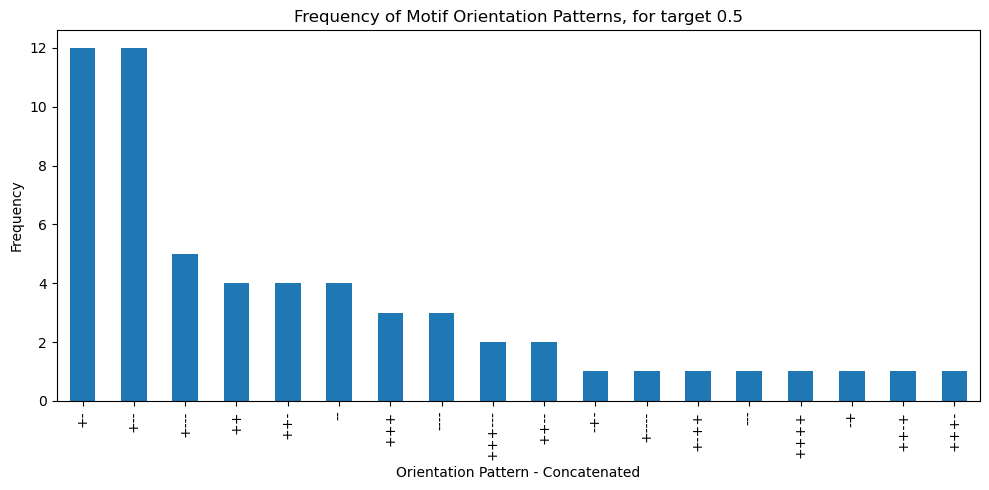

In [35]:
orientation_counts = df[df['orientation'] != "no"]['orientation'].value_counts()

# Plot
plt.figure(figsize=(10, 5))
orientation_counts.plot(kind='bar')
plt.xlabel("Orientation Pattern - Concatenated")
plt.ylabel("Frequency")
plt.title("Frequency of Motif Orientation Patterns, for target 0.5")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [15]:
df.columns

Index(['chrom', 'start', 'end', 'fold', 'PearsonR', 'flat_start', 'flat_end',
       'centered_start', 'centered_end', 'centered_flat_start',
       'centered_flat_end', 'last_accepted_step', 'SCD', 'dot_result',
       'dot_target', 'dot_init', 'num_edits_slice0', 'num_edits_slice1',
       'GC_seq', 'GC_slice0', 'GC_slice1', 'GC_slice0_edited',
       'GC_slice1_edited', 'init_CTCFs_num_slice0', 'CTCFs_num_slice0',
       'FIMO_sum_slice0', 'FIMO_max_slice0', 'orientation_slice0',
       'positions_slice0', 'init_CTCFs_num_slice1', 'CTCFs_num_slice1',
       'FIMO_sum_slice1', 'FIMO_max_slice1', 'orientation_slice1',
       'positions_slice1'],
      dtype='object')

In [22]:
df_melted = df.melt(value_vars=['dot_init', 'dot_result'], var_name='Type', value_name='dot strength')

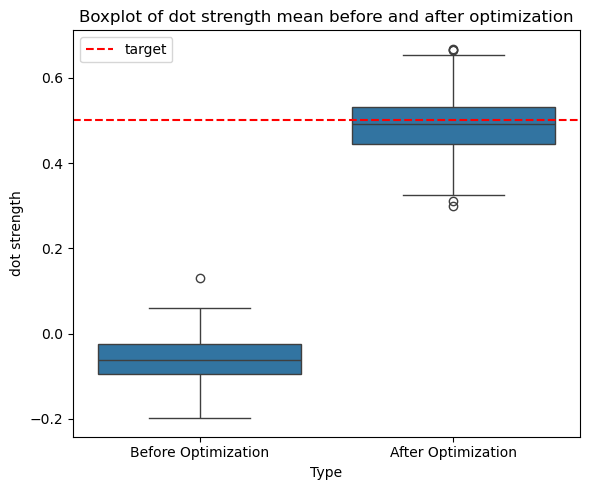

In [23]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Type', y='dot strength', data=df_melted)
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='target')
plt.xticks([0, 1], ['Before Optimization', 'After Optimization'])
plt.title('Boxplot of dot strength mean before and after optimization')
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
df["init_CTCFs_num"] = df["init_CTCFs_num_slice0"] + df["init_CTCFs_num_slice1"]
df["CTCFs_num"] = df["CTCFs_num_slice0"] + df["CTCFs_num_slice1"]

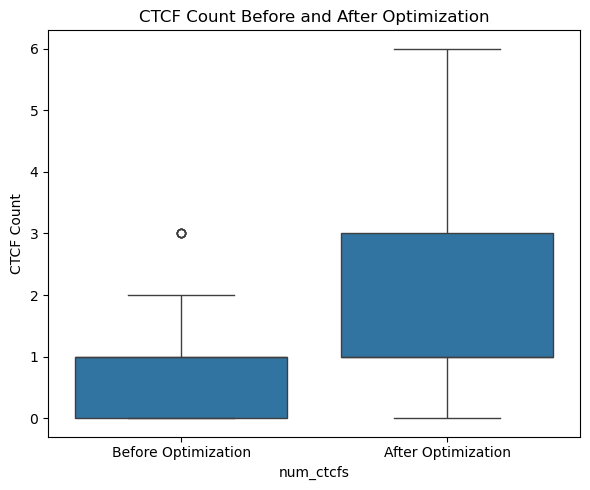

In [27]:
df_box_melted = df.melt(value_vars=['init_CTCFs_num', 'CTCFs_num'],
                            var_name='num_ctcfs', value_name='CTCF Count')

# Rename the categories for clarity
label_map = {
    'init_CTCFs_num': 'Before Optimization',
    'CTCFs_num': 'After Optimization'
}
df_box_melted['num_ctcfs'] = df_box_melted['num_ctcfs'].map(label_map)

# Plotting
plt.figure(figsize=(6, 5))
sns.boxplot(x='num_ctcfs', y='CTCF Count', data=df_box_melted)
plt.title('CTCF Count Before and After Optimization')
plt.tight_layout()
plt.show()

In [36]:
from scipy.stats import pearsonr

In [37]:
df.columns

Index(['chrom', 'start', 'end', 'fold', 'PearsonR', 'flat_start', 'flat_end',
       'centered_start', 'centered_end', 'centered_flat_start',
       'centered_flat_end', 'last_accepted_step', 'SCD', 'dot_result',
       'dot_target', 'dot_init', 'num_edits_slice0', 'num_edits_slice1',
       'GC_seq', 'GC_slice0', 'GC_slice1', 'GC_slice0_edited',
       'GC_slice1_edited', 'init_CTCFs_num_slice0', 'CTCFs_num_slice0',
       'FIMO_sum_slice0', 'FIMO_max_slice0', 'orientation_slice0',
       'positions_slice0', 'init_CTCFs_num_slice1', 'CTCFs_num_slice1',
       'FIMO_sum_slice1', 'FIMO_max_slice1', 'orientation_slice1',
       'positions_slice1', 'init_CTCFs_num', 'CTCFs_num', 'orientation'],
      dtype='object')

In [38]:
# Calculate Pearson correlation coefficient
r_value, p_value = pearsonr(df['dot_target'], df['dot_result'])

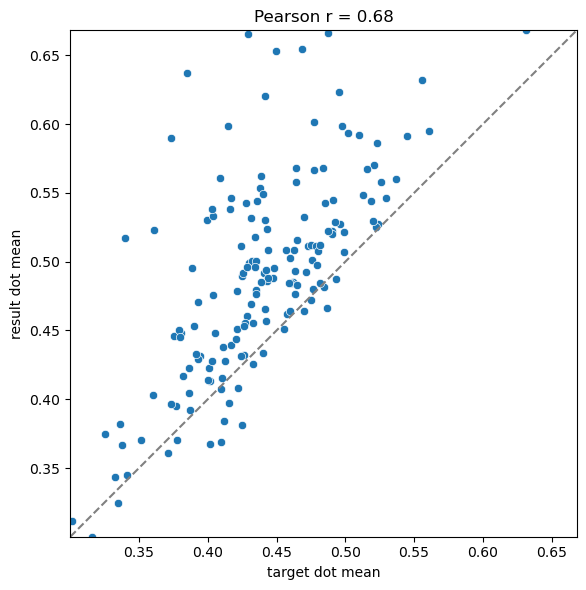

In [39]:
# Determine shared range for both axes
min_val = min(df['dot_target'].min(), df['dot_result'].min())
max_val = max(df['dot_target'].max(), df['dot_result'].max())

# Plotting the scatterplot with equal axis limits and square aspect ratio
plt.figure(figsize=(6, 6))
sns.scatterplot(x='dot_target', y='dot_result', data=df)
plt.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--')  # reference diagonal
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.gca().set_aspect('equal', adjustable='box')
plt.title(f'Pearson r = {r_value:.2f}')
plt.xlabel('target dot mean')
plt.ylabel('result dot mean')
plt.tight_layout()
plt.show()


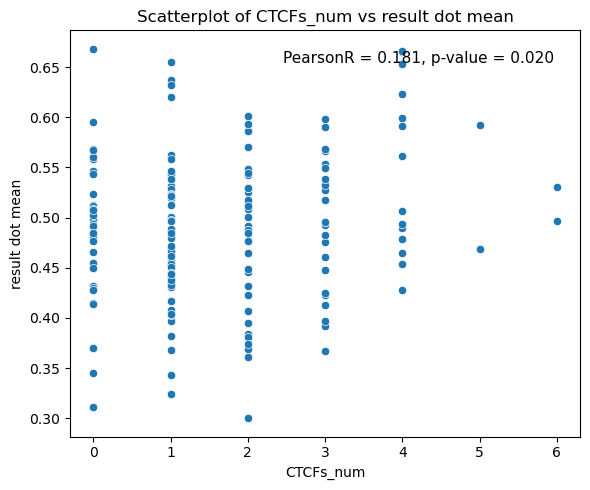

In [83]:

# Compute PearsonR and p-value
r, p = pearsonr(df['CTCFs_num'], df['dot_result'])

# Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='CTCFs_num', y='dot_result', data=df)

# Add labels and title
plt.xlabel('CTCFs_num')
plt.ylabel('result dot mean')
plt.title('Scatterplot of CTCFs_num vs result dot mean')

# Annotate PearsonR in top right corner
plt.text(
    0.95, 0.95,
    f"PearsonR = {r:.3f}, p-value = {p:.3f}",
    transform=plt.gca().transAxes,
    ha='right', va='top',
    fontsize=11, color='black'
)

plt.tight_layout()
plt.show()

In [43]:
df["FIMO_sum"] = df["FIMO_sum_slice0"] + df["FIMO_sum_slice1"]

In [45]:
df["FIMO_max"] = df[["FIMO_max_slice0", "FIMO_max_slice1"]].max(axis=1)

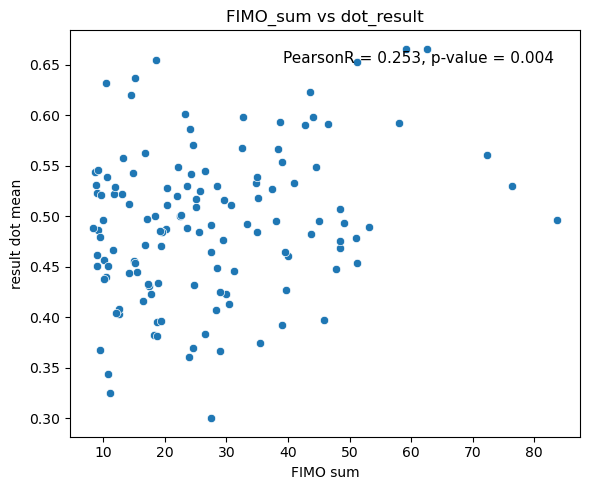

In [82]:
df_part = df[df["FIMO_sum"] > 0]

# Compute PearsonR and p-value
r, p = pearsonr(df_part['FIMO_sum'], df_part['dot_result'])

# Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='FIMO_sum', y='dot_result', data=df_part)

# Add labels and title
plt.xlabel('FIMO sum')
plt.ylabel('result dot mean')
plt.title('FIMO_sum vs dot_result')

# Annotate PearsonR in top right corner
plt.text(
    0.95, 0.95,
    f"PearsonR = {r:.3f}, p-value = {p:.3f}",
    transform=plt.gca().transAxes,
    ha='right', va='top',
    fontsize=11, color='black'
)

plt.tight_layout()
plt.show()

In [66]:
df["dot_diff"] = df["dot_result"] - df["dot_init"]

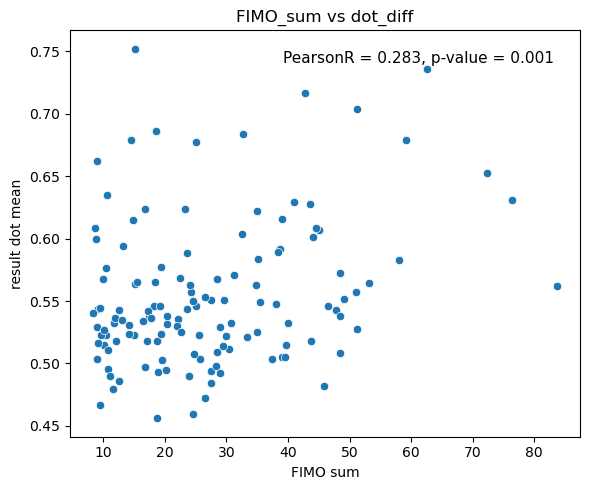

In [81]:
df_part = df[df["FIMO_sum"] > 0]

# Compute PearsonR and p-value
r, p = pearsonr(df_part['FIMO_sum'], df_part['dot_diff'])

# Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='FIMO_sum', y='dot_diff', data=df_part)

# Add labels and title
plt.xlabel('FIMO sum')
plt.ylabel('result dot mean')
plt.title('FIMO_sum vs dot_diff')

# Annotate PearsonR in top right corner
plt.text(
    0.95, 0.95,
    f"PearsonR = {r:.3f}, p-value = {p:.3f}",
    transform=plt.gca().transAxes,
    ha='right', va='top',
    fontsize=11, color='black'
)

plt.tight_layout()
plt.show()

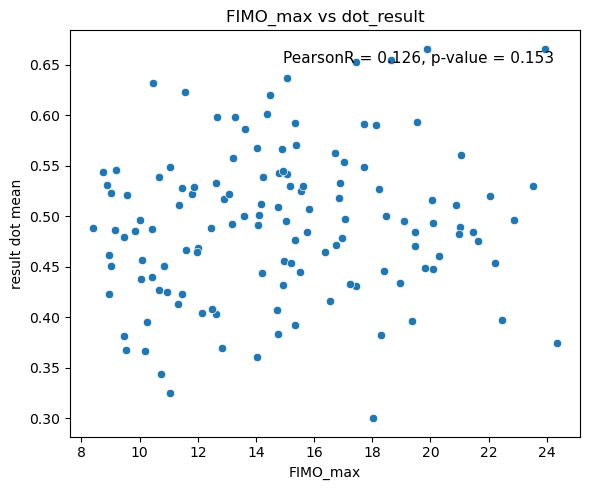

In [80]:
df_part = df[df["FIMO_max"] > 0]

# Compute PearsonR and p-value
r, p = pearsonr(df_part['FIMO_max'], df_part['dot_result'])

# Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='FIMO_max', y='dot_result', data=df_part)

# Add labels and title
plt.xlabel('FIMO_max')
plt.ylabel('result dot mean')
plt.title('FIMO_max vs dot_result')

# Annotate PearsonR in top right corner
plt.text(
    0.95, 0.95,
    f"PearsonR = {r:.3f}, p-value = {p:.3f}",
    transform=plt.gca().transAxes,
    ha='right', va='top',
    fontsize=11, color='black'
)

plt.tight_layout()
plt.show()

In [49]:
df.columns

Index(['chrom', 'start', 'end', 'fold', 'PearsonR', 'flat_start', 'flat_end',
       'centered_start', 'centered_end', 'centered_flat_start',
       'centered_flat_end', 'last_accepted_step', 'SCD', 'dot_result',
       'dot_target', 'dot_init', 'num_edits_slice0', 'num_edits_slice1',
       'GC_seq', 'GC_slice0', 'GC_slice1', 'GC_slice0_edited',
       'GC_slice1_edited', 'init_CTCFs_num_slice0', 'CTCFs_num_slice0',
       'FIMO_sum_slice0', 'FIMO_max_slice0', 'orientation_slice0',
       'positions_slice0', 'init_CTCFs_num_slice1', 'CTCFs_num_slice1',
       'FIMO_sum_slice1', 'FIMO_max_slice1', 'orientation_slice1',
       'positions_slice1', 'init_CTCFs_num', 'CTCFs_num', 'orientation',
       'FIMO_sum', 'FIMO_max'],
      dtype='object')

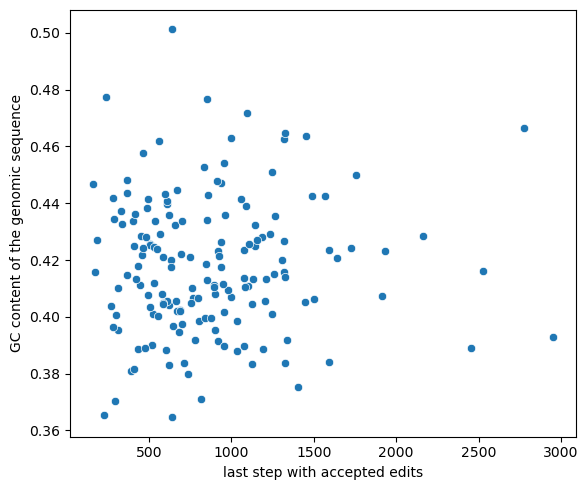

In [51]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='last_accepted_step',
    y='GC_seq',
    data=df
)
plt.xlabel('last step with accepted edits')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

In [52]:
df.columns

Index(['chrom', 'start', 'end', 'fold', 'PearsonR', 'flat_start', 'flat_end',
       'centered_start', 'centered_end', 'centered_flat_start',
       'centered_flat_end', 'last_accepted_step', 'SCD', 'dot_result',
       'dot_target', 'dot_init', 'num_edits_slice0', 'num_edits_slice1',
       'GC_seq', 'GC_slice0', 'GC_slice1', 'GC_slice0_edited',
       'GC_slice1_edited', 'init_CTCFs_num_slice0', 'CTCFs_num_slice0',
       'FIMO_sum_slice0', 'FIMO_max_slice0', 'orientation_slice0',
       'positions_slice0', 'init_CTCFs_num_slice1', 'CTCFs_num_slice1',
       'FIMO_sum_slice1', 'FIMO_max_slice1', 'orientation_slice1',
       'positions_slice1', 'init_CTCFs_num', 'CTCFs_num', 'orientation',
       'FIMO_sum', 'FIMO_max'],
      dtype='object')

In [54]:
df["num_edits"] = df["num_edits_slice0"] + df["num_edits_slice1"] 

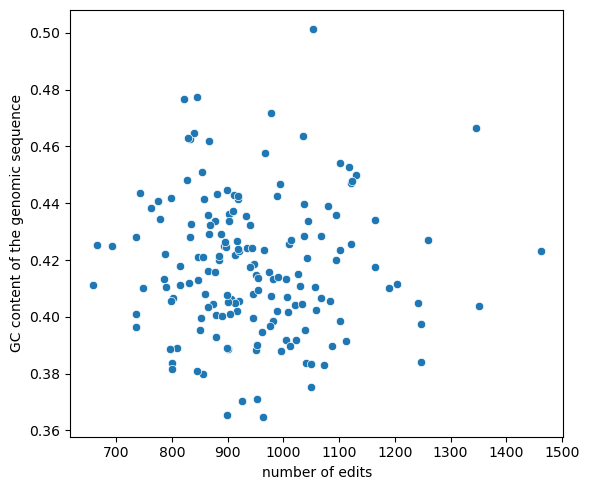

In [56]:
plt.figure(figsize=(6, 5))

sns.scatterplot(
    x='num_edits',
    y='GC_seq',
    data=df
)

plt.xlabel('number of edits')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

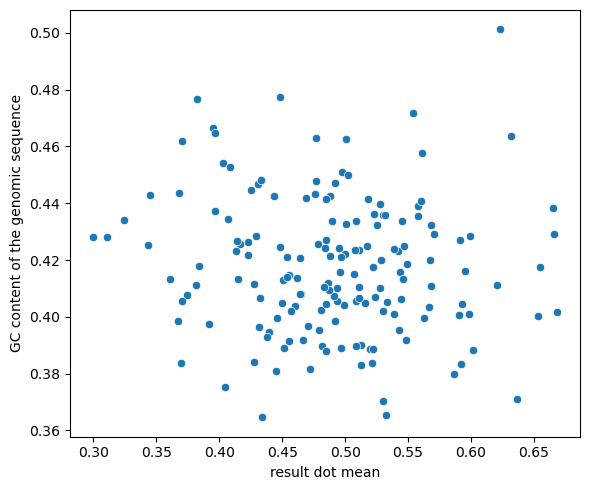

In [57]:
plt.figure(figsize=(6, 5))

sns.scatterplot(
    x='dot_result',
    y='GC_seq',
    data=df
)

plt.xlabel('result dot mean')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

In [ ]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='active_fraction',
    y='last_accepted_step_query',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Active Chromatin Fraction')
plt.ylabel('Last Step with Accepted Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()


In [ ]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='neutral_fraction',
    y='last_accepted_step_query',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Neutral Chromatin Fraction')
plt.ylabel('Last Step with Accepted Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

In [ ]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='repressive_fraction',
    y='last_accepted_step_query',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Repressive Chromatin Fraction')
plt.ylabel('Last Step with Accepted Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

In [ ]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='active_fraction',
    y='num_edits',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Active Chromatin Fraction')
plt.ylabel('Number of Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

In [ ]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='neutral_fraction',
    y='num_edits',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Neutral Chromatin Fraction')
plt.ylabel('Number of Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

In [ ]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='repressive_fraction',
    y='num_edits',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Repressive Chromatin Fraction')
plt.ylabel('Number of Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

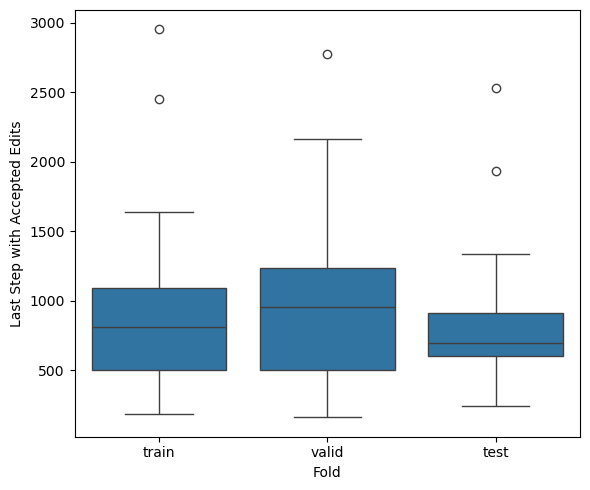

In [69]:
fold_map = {0: 'test', 1: 'valid', 2: 'train'}
df['set'] = df['fold'].map(fold_map)

# Plotting the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='set', y='last_accepted_step', data=df, order=['train', 'valid', 'test'])
plt.xlabel('Fold')
plt.ylabel('Last Step with Accepted Edits')
plt.tight_layout()
plt.show()

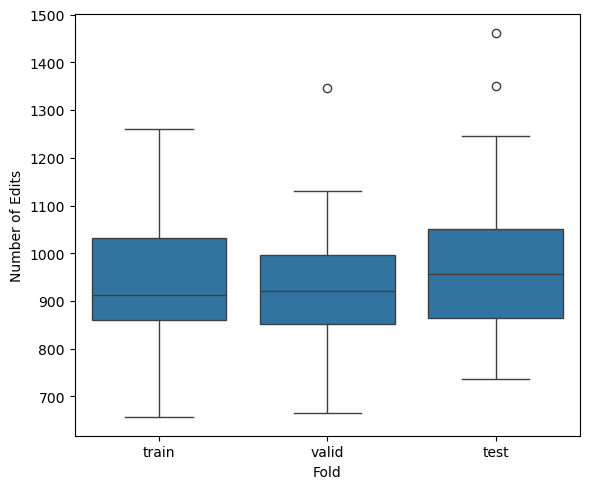

In [70]:
# Plotting the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='set', y='num_edits', data=df, order=['train', 'valid', 'test'])
plt.xlabel('Fold')
plt.ylabel('Number of Edits')
plt.tight_layout()
plt.show()

In [71]:
from scipy.stats import ttest_rel

In [73]:
df.columns

Index(['chrom', 'start', 'end', 'fold', 'PearsonR', 'flat_start', 'flat_end',
       'centered_start', 'centered_end', 'centered_flat_start',
       'centered_flat_end', 'last_accepted_step', 'SCD', 'dot_result',
       'dot_target', 'dot_init', 'num_edits_slice0', 'num_edits_slice1',
       'GC_seq', 'GC_slice0', 'GC_slice1', 'GC_slice0_edited',
       'GC_slice1_edited', 'init_CTCFs_num_slice0', 'CTCFs_num_slice0',
       'FIMO_sum_slice0', 'FIMO_max_slice0', 'orientation_slice0',
       'positions_slice0', 'init_CTCFs_num_slice1', 'CTCFs_num_slice1',
       'FIMO_sum_slice1', 'FIMO_max_slice1', 'orientation_slice1',
       'positions_slice1', 'init_CTCFs_num', 'CTCFs_num', 'orientation',
       'FIMO_sum', 'FIMO_max', 'num_edits', 'dot_diff', 'set'],
      dtype='object')

In [74]:
t_stat, p_val = ttest_rel(df['GC_slice0'], df['GC_slice0_edited'])

In [75]:
t_stat, p_val

(-14.47940120655653, 4.467002708105656e-31)

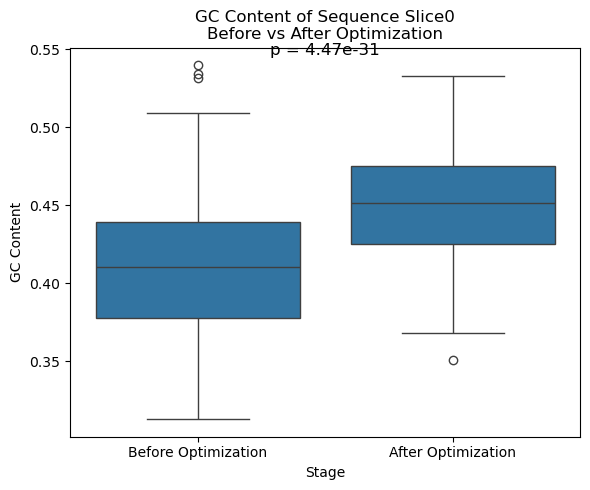

In [77]:
# Melt the DataFrame for plotting
df_gc_melted = df.melt(value_vars=['GC_slice0', 'GC_slice0_edited'],
                          var_name='Stage', value_name='GC Content')

# Rename the stages for clarity
stage_map = {
    'GC_slice0': 'Before Optimization',
    'GC_slice0_edited': 'After Optimization'
}
df_gc_melted['Stage'] = df_gc_melted['Stage'].map(stage_map)

# Plotting the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='Stage', y='GC Content', data=df_gc_melted)
plt.title('GC Content of Sequence Slice0\nBefore vs After Optimization')
plt.text(0.5, max(df_gc_melted['GC Content']) + 0.005,
         f'p = {p_val:.3g}', ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

In [78]:
t_stat, p_val = ttest_rel(df['GC_slice1'], df['GC_slice1_edited'])

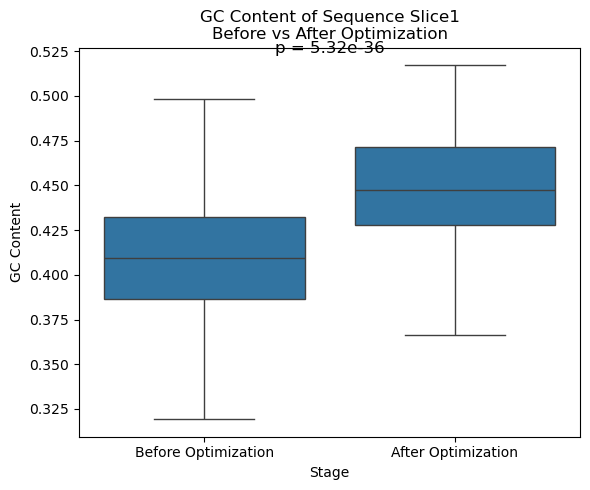

In [79]:
# Melt the DataFrame for plotting
df_gc_melted = df.melt(value_vars=['GC_slice1', 'GC_slice1_edited'],
                          var_name='Stage', value_name='GC Content')

# Rename the stages for clarity
stage_map = {
    'GC_slice1': 'Before Optimization',
    'GC_slice1_edited': 'After Optimization'
}
df_gc_melted['Stage'] = df_gc_melted['Stage'].map(stage_map)

# Plotting the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='Stage', y='GC Content', data=df_gc_melted)
plt.title('GC Content of Sequence Slice1\nBefore vs After Optimization')
plt.text(0.5, max(df_gc_melted['GC Content']) + 0.005,
         f'p = {p_val:.3g}', ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()